In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel("FoodAccessResearchAtlasData2019.xlsx", sheet_name="Food Access Research Atlas")
lookup = pd.read_excel("FoodAccessResearchAtlasData2019.xlsx", sheet_name="Variable Lookup")

In [3]:
print(f"Data loaded. Shape: {df.shape}")

Data loaded. Shape: (72531, 147)


In [4]:
# Filter to Illinois
df_il = df[df['State'] == 'Illinois']

# Filter to Cook County
df_cook = df_il[df_il['County'] == 'Cook County'].copy()

print(f"Cook County rows: {df_cook.shape[0]}")

Cook County rows: 1314


In [5]:
# Check missing values for key variables
key_vars = ['PovertyRate', 'lapop1share', 'lalowi1share', 'lahunv1share', 'lasnap1share', 'MedianFamilyIncome']

print("Missing values before cleaning:")
print(df_cook[key_vars].isna().sum())

# Replace NaNs in the 'share' variables with 0
share_vars = ['lapop1share', 'lalowi1share', 'lahunv1share', 'lasnap1share']
df_cook[share_vars] = df_cook[share_vars].fillna(0)

# For income/poverty, fill with median
df_cook['PovertyRate'] = df_cook['PovertyRate'].fillna(df_cook['PovertyRate'].median())
df_cook['MedianFamilyIncome'] = df_cook['MedianFamilyIncome'].fillna(df_cook['MedianFamilyIncome'].median())

print("Missing values after cleaning:")
print(df_cook[key_vars].isna().sum())

Missing values before cleaning:
PovertyRate             0
lapop1share           972
lalowi1share          972
lahunv1share          972
lasnap1share          972
MedianFamilyIncome      9
dtype: int64
Missing values after cleaning:
PovertyRate           0
lapop1share           0
lalowi1share          0
lahunv1share          0
lasnap1share          0
MedianFamilyIncome    0
dtype: int64


# Create a Correlation Matrix

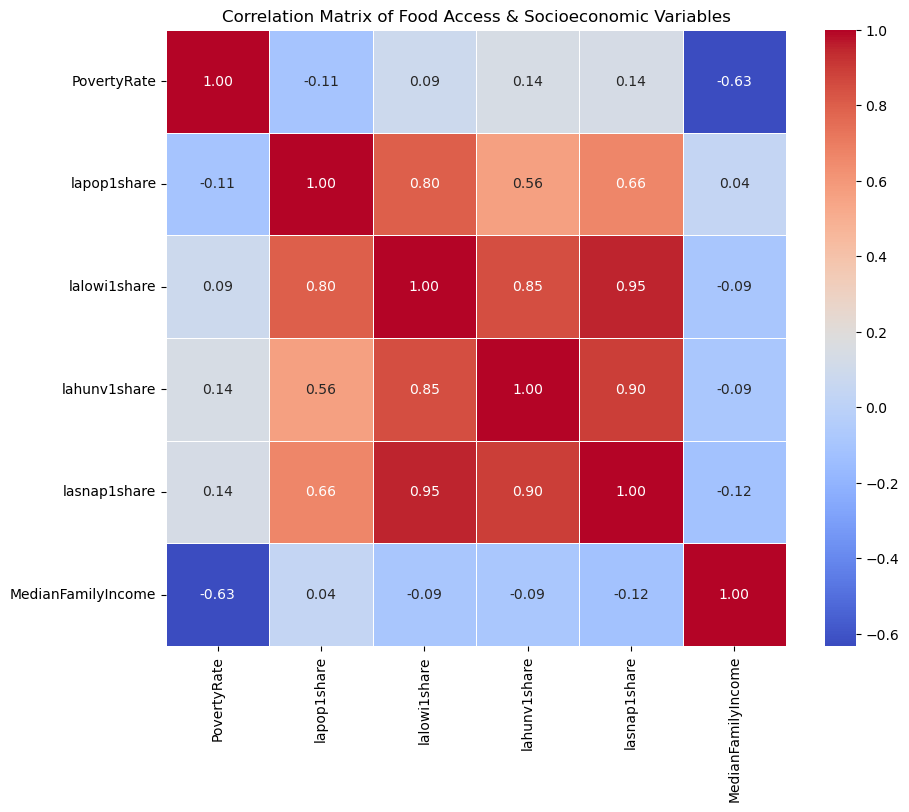

In [6]:
# Select the raw variables used in the index
index_vars = ['PovertyRate', 'lapop1share', 'lalowi1share', 'lahunv1share', 'lasnap1share', 'MedianFamilyIncome']

# Correlation matrix betwween the variables.
corr_matrix = df_cook[index_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Food Access & Socioeconomic Variables')
plt.show()

# Bubble Chart

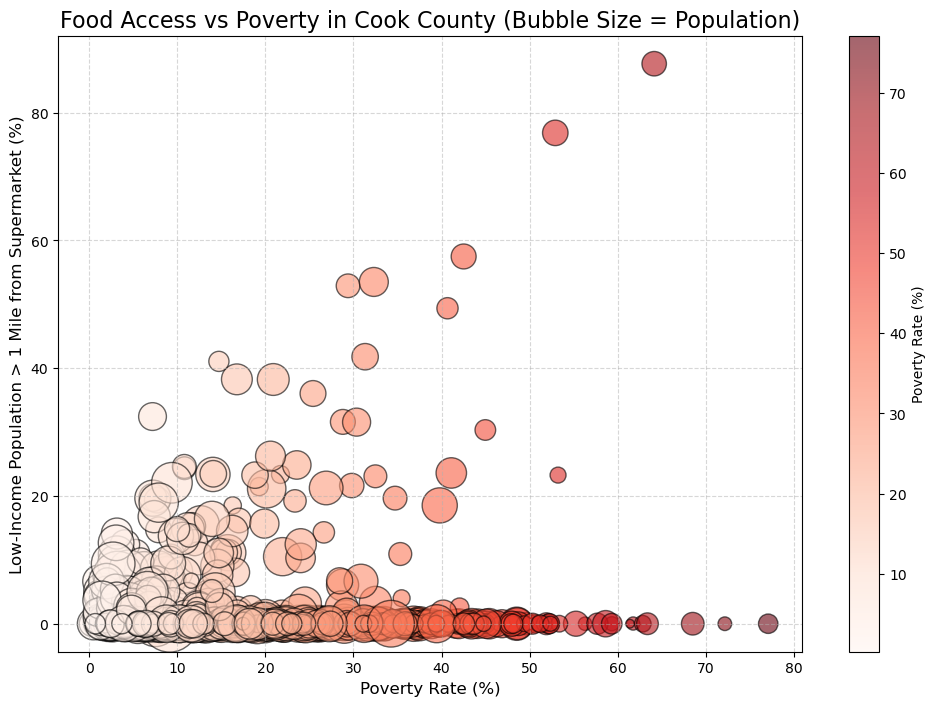

In [7]:
# Create Bubble Scatter plot
plt.figure(figsize=(12, 8))

# Create the scatter plot
# x = Poverty Rate
# y = Low-income population > 1 mile from supermarket
# s = Population size (divid by 10 for visualization)
# c = Poverty Rate (so the color matches the x-axis)
# alpha = 0.6 (make bubbles slightly transparent so you can see overlapping ones)
plt.scatter(
    df_cook['PovertyRate'],
    df_cook['lalowi1share'],
    s=df_cook['Pop2010']/10,
    c=df_cook['PovertyRate'],
    cmap='Reds',
    alpha=0.6,
    edgecolors='black'
)

# Labels and title
plt.title('Food Access vs Poverty in Cook County (Bubble Size = Population)', fontsize=16)
plt.xlabel('Poverty Rate (%)', fontsize=12)
plt.ylabel('Low-Income Population > 1 Mile from Supermarket (%)', fontsize=12)
plt.colorbar(label='Poverty Rate (%)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### ⬆️ To understand the relationship between poverty rates & how many low-income people live > 1 mile from a supermarket I made a bubble chart. The size of the bubble represents the total population of that census tract. This helps us spot what areas have both high poverty & poor food acces.

In [8]:
# 1 Summary table that describes the bubble chart findings
# Use pd.cut to group tracts into "Poverty Bands" in prder to summarize them
df_cook['PovertyBand'] = pd.cut(
    df_cook['PovertyRate'],
    bins=[0, 10, 20, 30, 100],
    labels=['Low (0-10%)', 'Moderate (10-20%)', 'High (20-30%)', 'Very High (>30%)']
)

# Build summary table
summary = df_cook.groupby('PovertyBand', observed=True).agg(
    Tracts=('CensusTract', 'count'),
    Total_Population=('Pop2010', 'sum'),
    Avg_Food_Access_Issue=('lalowi1share', 'mean'),
    Avg_No_Vehicle_Issue=('lahunv1share', 'mean'),
    Avg_SNAP_Issue=('lasnap1share', 'mean')
).round(1)

# Add column that shows what % of Cook County's total population lives in each band
total_pop = df_cook['Pop2010'].sum()
summary['Pct_of_County_Pop'] = (summary['Total_Population'] / total_pop * 100).round(1)

# Renamed columns for readability
summary.columns = [
    'Number of Tracts',
    'Total Population',
    'Avg % Low-Income >1 Mile from Store',
    'Avg % No Vehicle >1 Mile from Store',
    'Avg % SNAP >1 Mile from Store',
    '% of County Population'
]

# Display the table
print("SUMMARY TABLE: Food Access by Poverty Level in Cook County")
display(summary)

SUMMARY TABLE: Food Access by Poverty Level in Cook County


,Number of Tracts,Total Population,Avg % Low-Income >1 Mile from Store,Avg % No Vehicle >1 Mile from Store,Avg % SNAP >1 Mile from Store,% of County Population
PovertyBand,,,,,,
Low (0-10%),505,2185108,1.3,0.3,0.5,42.1
Moderate (10-20%),362,1512430,1.5,0.3,0.6,29.1
High (20-30%),228,858030,1.7,0.5,1.1,16.5
Very High (>30%),219,639107,2.6,1.2,1.7,12.3


# Top 10 Bar Graph

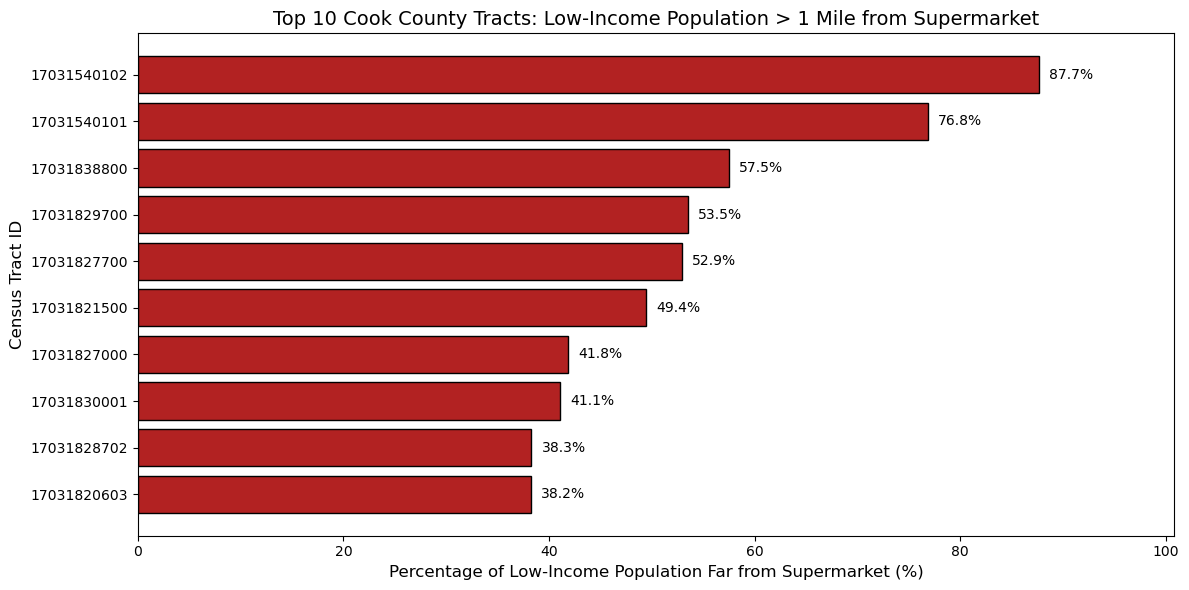

In [9]:
import matplotlib.pyplot as plt

# Sort data to find the top 10 tracts
top_10 = df_cook.sort_values('lalowi1share', ascending=False).head(10)

# Create the bar chart using matplotlib
plt.figure(figsize=(12, 6))

# Create the bars
plt.barh(top_10['CensusTract'].astype(str), top_10['lalowi1share'], color='firebrick', edgecolor='black')

# labels and title
plt.title('Top 10 Cook County Tracts: Low-Income Population > 1 Mile from Supermarket', fontsize=14)
plt.xlabel('Percentage of Low-Income Population Far from Supermarket (%)', fontsize=12)
plt.ylabel('Census Tract ID', fontsize=12)

# 4. Add the percentages at the end og each bar
# Loop through values and place text slightly to the right
for index, value in enumerate(top_10['lalowi1share']):
    plt.text(value + 1, index, f'{value:.1f}%', va='center', fontsize=10)

# Invert y-axis so highest value ends up at the top
plt.gca().invert_yaxis()

# Add a little extra space on the right, some nums get cut off otherwise
plt.xlim(0, top_10['lalowi1share'].max() * 1.15)

plt.tight_layout()
plt.show()

### ⬆️ Chart shows top 10 sensus tracts in Cook County - based on % of low-income residents that live > 1 from a supermarket. Tract 17031540102 has the most severe food access challenge for low-income residents. These insights can help nonprofit organizations focus their outreach efforts in areas with the most need.

# Bar Graph Food Access Burden

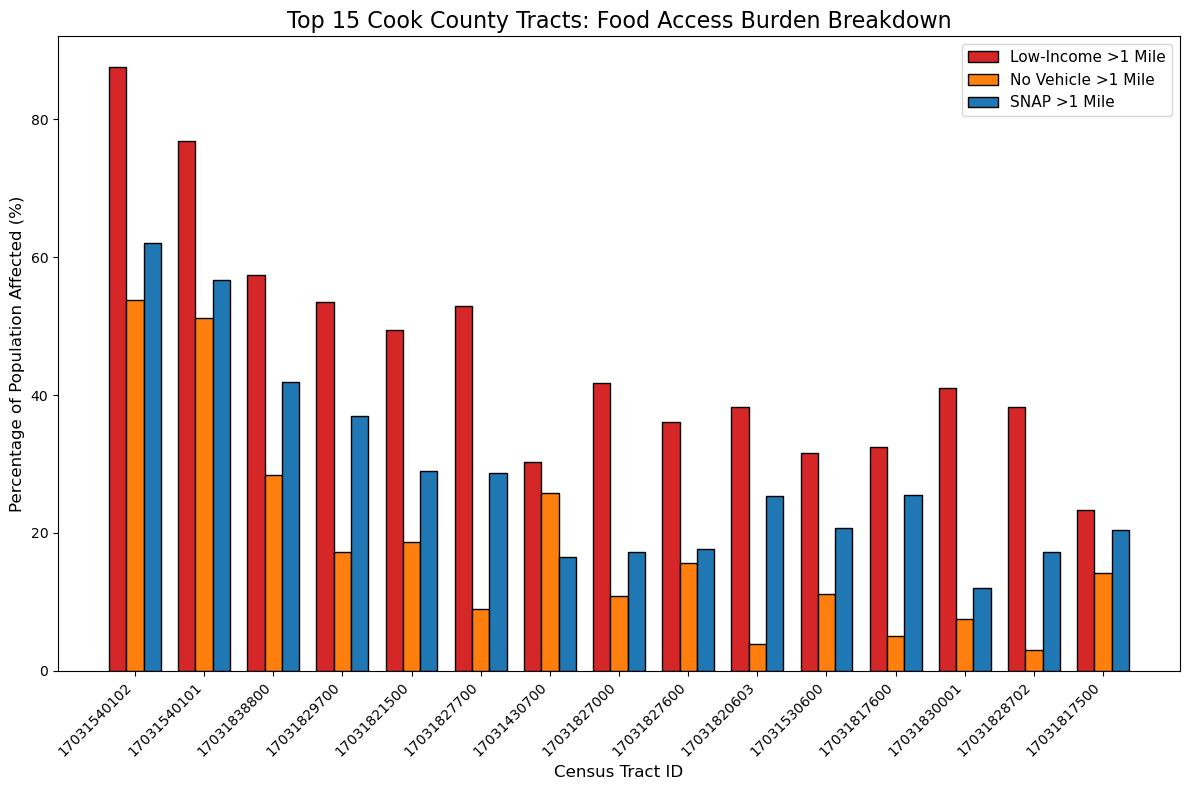

In [10]:
# Get the top 15 tracts by combined food access burden
# Create simple combined measure of the three food access variables
df_cook['FoodAccessBurden'] = (
    df_cook['lalowi1share'] +
    df_cook['lahunv1share'] +
    df_cook['lasnap1share']
) / 3

top_15 = df_cook.sort_values('FoodAccessBurden', ascending=False).head(15)

# Create the chart
fig, ax = plt.subplots(figsize=(12, 8))

# Set bar positions
x = np.arange(len(top_15))
width = 0.25

# Create three sets of bars for the three food access measures
bars1 = ax.bar(x - width, top_15['lalowi1share'], width, label='Low-Income >1 Mile', color='#d62728', edgecolor='black')
bars2 = ax.bar(x, top_15['lahunv1share'], width, label='No Vehicle >1 Mile', color='#ff7f0e', edgecolor='black')
bars3 = ax.bar(x + width, top_15['lasnap1share'], width, label='SNAP >1 Mile', color='#1f77b4', edgecolor='black')

# Add labels and title
ax.set_title('Top 15 Cook County Tracts: Food Access Burden Breakdown', fontsize=16)
ax.set_xlabel('Census Tract ID', fontsize=12)
ax.set_ylabel('Percentage of Population Affected (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(top_15['CensusTract'].astype(str), rotation=45, ha='right')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### ⬆️ Chart shows top 15 most burdened tracts, combining three food access measures. This visualization breaks down three key measures - low-income residents far from a store, households without vehicles far from a store, and SNAP recipients far from a store. Some tracts have higher burdens in all three categories. This helps us understand which tracts have the greatest need.